# Wave Pulse Motion Primitive Experiment

This notebook demonstrates and visualizes the `_pulse_wave_generator` function from `animgen.animation.wave` which generates a localized wave pulse propagating along an armature's spine in the positive x direction.

## 1. What is a Wave Pulse?
Unlike continuous travelling or standing waves, a **wave pulse** represents a localized wave packet that starts at a specific spatial position (`pulse_center`, default $s_0 = 0.0$) and propagates across the armature over time.
It is modeled using a localized Gaussian envelope modulating a wave carrier:

$$u(s, t) = A \exp(g s) \exp\left( -\frac{\xi(s, t)^2}{2 \sigma^2} \right) \cos(\xi(s, t))$$

where:
- $\xi(s, t) = k (s - s_0) - \omega t + \phi_s + \phi_t$ is the wave phase
- $s_0$ is `pulse_center` (initial location of pulse peak at $t = 0$)
- $k = \frac{2\pi N}{L}$ is the spatial wave number ($N$ = `num_waves`, $L$ = total length)
- $\omega = \frac{2\pi}{T}$ is the temporal angular frequency ($T$ = `wave_duration`)
- $\sigma$ is the `pulse_width` parameter
- $g$ is the `growth_factor`

At $t = 0$, the pulse peak is centered directly at $s = s_0$ (the root of the armature when $s_0 = 0.0$).
As time $t$ increases, the center of the pulse envelope ($\xi = 0$) moves along $+s$ (positive x direction) with phase velocity $v = \frac{\omega}{k} = \frac{L}{N T}$.

Like travelling and standing waves, `_pulse_wave_generator` uses tangent-vector integration and `successive_rotations` to ensure that **bone lengths are perfectly conserved** (rigid bones) throughout the animation.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Ensure workspace root is in path to import animgen
sys.path.append(os.path.abspath('..'))

from animgen.animation.wave import _pulse_wave_generator, chain_wave_generator

def reconstruct_positions_from_rotations(distances, rotations):
    bind_positions = np.stack([distances, np.zeros_like(distances), np.zeros_like(distances)], axis=-1)
    bind_vectors = np.diff(bind_positions, axis=0)
    positions = [np.array([0.0, 0.0, 0.0])]
    R_accum = np.eye(3)
    for i, R_local in enumerate(rotations):
        if hasattr(R_local, 'detach'):
            R_local = R_local.detach().cpu().numpy()
        R_accum = R_local @ R_accum
        positions.append(positions[-1] + R_accum @ bind_vectors[i])
    positions = np.array(positions)
    positions[:, 1] = positions[:, 1] - np.mean(positions[:, 1])
    return positions

## 2. Verification of Bone Length Preservation
We run `_pulse_wave_generator` on a multi-segment armature chain and calculate the Euclidean distance between successive joint positions across multiple time frames to verify bone rigidity.

In [2]:
distances = np.linspace(0.0, 5.0, 11)  # 10 segments of length 0.5 each
wave_amplitude = 0.4
wave_duration = 2.0
time_stamps = [0.0, 0.5, 1.0, 1.5]

animation = _pulse_wave_generator(
    distances=distances,
    wave_amplitude=wave_amplitude,
    wave_duration=wave_duration,
    time_stamps=time_stamps,
    growth_factor=0.1,
    num_waves=1.5,
    pulse_width=1.2,
    pulse_center=0.0,
    phi_s=0.0,
    phi_t=0.0
)

print("Verifying Segment Lengths for each frame of the Pulse Wave:")
expected_lengths = np.diff(distances)

for t, frame in animation.items():
    pts = reconstruct_positions_from_rotations(distances, frame)
    actual_lengths = []
    for i in range(1, len(pts)):
        p1 = pts[i-1]
        p2 = pts[i]
        actual_lengths.append(np.linalg.norm(p2 - p1))
    
    diff = np.linalg.norm(expected_lengths - np.array(actual_lengths))
    print(f"Time {t:.2f}s: Max Length Diff = {diff:.2e} (Expected: {expected_lengths[0]}, Actual Mean: {np.mean(actual_lengths):.6f})")

Verifying Segment Lengths for each frame of the Pulse Wave:
Time 0.00s: Max Length Diff = 1.14e-15 (Expected: 0.5, Actual Mean: 0.500000)
Time 0.50s: Max Length Diff = 1.47e-15 (Expected: 0.5, Actual Mean: 0.500000)
Time 1.00s: Max Length Diff = 6.38e-16 (Expected: 0.5, Actual Mean: 0.500000)
Time 1.50s: Max Length Diff = 1.55e-15 (Expected: 0.5, Actual Mean: 0.500000)


## 3. Static Wave Pulse Visualization (Starting at s = 0 and Propagating in Positive X)
We plot the shape of the armature chain across consecutive time steps ($t = 0.0s, 0.4s, 0.8s, 1.2s, 1.6s, 2.0s$) to visualize the localized pulse starting at the root ($s=0$) and traveling from left to right (+X direction).

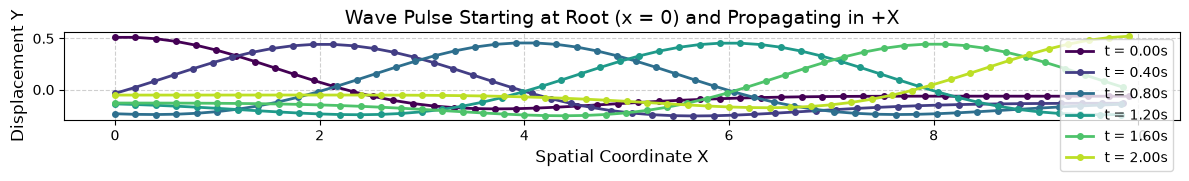

In [3]:
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 6))

total_length = 10.0
distances = np.linspace(0.0, total_length, 51)
wave_amplitude = 0.6
wave_duration = 2.0
pulse_width = 1.5
num_waves = 1.0

time_stamps = np.linspace(0.0, 2.0, 6)

animation = _pulse_wave_generator(
    distances=distances,
    wave_amplitude=wave_amplitude,
    wave_duration=wave_duration,
    time_stamps=time_stamps,
    growth_factor=0.0,
    num_waves=num_waves,
    pulse_width=pulse_width,
    pulse_center=0.0,
)

colors = plt.cm.viridis(np.linspace(0, 0.9, len(time_stamps)))

for (t, frame), color in zip(animation.items(), colors):
    pts = reconstruct_positions_from_rotations(distances, frame)
    ax.plot(pts[:, 0], pts[:, 1], '-o', label=f't = {t:.2f}s', color=color, linewidth=2, markersize=4)

ax.set_title('Wave Pulse Starting at Root (x = 0) and Propagating in +X', fontsize=14)
ax.set_xlabel('Spatial Coordinate X', fontsize=12)
ax.set_ylabel('Displacement Y', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')
ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

## 4. Interactive Wave Pulse Explorer (Flicker-Free Simulator)
Use the `Play` widget and configurable parameter sliders (including `Pulse Center`) to animate the wave pulse starting at a specific point and propagating in the positive x direction.

In [ ]:
from ipywidgets import FloatSlider, IntSlider, Play, jslink, HBox, VBox
import ipywidgets as widgets
from IPython.display import display

plt.close('all')

# Set up the Play widget for loop animation (frames 0 to 99)
play = Play(
    value=0,
    min=0,
    max=99,
    step=1,
    interval=40,  # ~25 FPS for smooth updates
    description="Play",
    loop=True
)

frame_slider = IntSlider(value=0, min=0, max=99, description='Frame')
jslink((play, 'value'), (frame_slider, 'value'))

# Configurable parameter sliders
amplitude_slider = FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1, description='Amplitude')
width_slider = FloatSlider(value=1.5, min=0.3, max=5.0, step=0.1, description='Pulse Width')
center_slider = FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.5, description='Pulse Center')
growth_slider = FloatSlider(value=0.0, min=-0.5, max=0.5, step=0.05, description='Growth Rate')
waves_slider = FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description='Num Waves')
speed_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Wave Speed')
phi_s_slider = FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.1, description='Phase Spatial')
phi_t_slider = FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.1, description='Phase Temporal')

def plot_interactive(frame, wave_amplitude, pulse_width, pulse_center, growth_factor, num_waves, wave_speed, phi_s, phi_t):
    plt.close('all')

    distances = np.linspace(0.0, 10.0, 100)
    wave_duration = 2.0  # Base duration

    base_time = (frame / 100.0) * wave_duration
    effective_time = base_time * wave_speed

    animation = _pulse_wave_generator(
        distances=distances,
        wave_amplitude=wave_amplitude,
        wave_duration=wave_duration,
        time_stamps=effective_time,
        growth_factor=growth_factor,
        num_waves=num_waves,
        pulse_width=pulse_width,
        pulse_center=pulse_center,
        phi_s=phi_s,
        phi_t=phi_t
    )

    pts = reconstruct_positions_from_rotations(distances, list(animation.values())[0])

    plt.figure(figsize=(12, 6))

    # Draw current pulse wave state
    plt.plot(pts[:, 0], pts[:, 1], 'r-o', linewidth=2.5, markersize=5, label=f"Wave Pulse (t = {effective_time:.2f}s)")

    # Draw Gaussian envelope reference bounds
    wave_number = 2 * np.pi * num_waves / 10.0
    angular_frequency = 2 * np.pi / wave_duration
    phase = wave_number * (distances - pulse_center) - angular_frequency * effective_time + phi_s + phi_t
    envelope = wave_amplitude * np.exp(growth_factor * distances) * np.exp(-0.5 * (phase / pulse_width) ** 2)

    plt.plot(pts[:, 0], envelope, 'k--', alpha=0.4, label="Gaussian Envelope (+)")
    plt.plot(pts[:, 0], -envelope, 'k--', alpha=0.4, label="Gaussian Envelope (-)")

    max_env = wave_amplitude * np.exp(max(0, growth_factor) * 10.0)
    plt.ylim(-max_env * 1.25, max_env * 1.25)
    plt.xlim(-0.5, 10.5)

    plt.title("Flicker-Free Animated Wave Pulse Simulator (+X Direction)", fontsize=14)
    plt.xlabel("X Coordinate (s)", fontsize=12)
    plt.ylabel("Y Coordinate (Displacement)", fontsize=12)
    plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
    plt.grid(True, alpha=0.2)
    plt.legend(loc="upper left")
    plt.show()

# Connect widgets using interactive_output to buffer output and prevent flickering
out = widgets.interactive_output(
    plot_interactive,
    {
        'frame': frame_slider,
        'wave_amplitude': amplitude_slider,
        'pulse_width': width_slider,
        'pulse_center': center_slider,
        'growth_factor': growth_slider,
        'num_waves': waves_slider,
        'wave_speed': speed_slider,
        'phi_s': phi_s_slider,
        'phi_t': phi_t_slider
    }
)

controls = VBox([
    HBox([play, frame_slider]),
    HBox([amplitude_slider, width_slider, center_slider]),
    HBox([waves_slider, growth_slider, speed_slider]),
    HBox([phi_s_slider, phi_t_slider])
])

display(controls, out)

Output()